# Self-Supervised Rotation Pretraining on STL10

In [2]:
import random
from collections import Counter
from copy import deepcopy
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import STL10
from torchvision.models import resnet18
from torchvision.transforms import functional
from tqdm import tqdm

import json


In [3]:
SEED = 42
SSL_VAL_FRACTION = 0.1
SSL_BATCH_SIZE = 128
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
SSL_LR = 0.05
SSL_MOMENTUM = 0.9
SSL_WEIGHT_DECAY = 5e-4
SSL_OUT_DIR = Path("/content/drive/MyDrive/ssl_pretrain")
SSL_BACKBONE_PATH = SSL_OUT_DIR / "ssl_backbone.pth"
SSL_HISTORY_PATH = SSL_OUT_DIR / "ssl_history.json"
SSL_FIG_PATH = SSL_OUT_DIR / "ssl_curves.png"
SSL_EPOCHS = 40
SSL_PATIENCE = 8

In [ ]:
print("No local output folders. All SSL files go to Google Drive after mount.")

Directories 'results/' and 'figures/' are ready.


In [ ]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

set_seed(SEED)
DEVICE = get_device()
print("Device:", DEVICE)

Device: cuda


## Part 1.3. Create the STL10 rotation-prediction dataset


Each original unlabeled image produces exactly four examples. Labels
{0, 1, 2, 3} mean rotations {0°, 90°, 180°, 270°}.

In [ ]:
class STL10RotationDataset(Dataset):
    def __init__(self, base_dataset, transform=None):
        self.base_dataset = base_dataset
        self.transform = transform
        self.angles = (0, 90, 180, 270)

    def __len__(self):
        return 4 * len(self.base_dataset)

    def __getitem__(self, index):
        # Map index to base image and rotation angle
        base_idx = index // 4
        rotation_label = index % 4

        # Access the image from the base dataset
        image, _ = self.base_dataset[base_idx]

        # Apply rotation
        image = functional.rotate(image, self.angles[rotation_label])

        # Apply further transformations (like ToTensor and Normalize)
        if self.transform is not None:
            image = self.transform(image)

        return image, rotation_label

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

drive_path = "/content/drive/MyDrive/stl10_data"
os.makedirs(drive_path, exist_ok=True)

SSL_OUT_DIR = Path("/content/drive/MyDrive/ssl_pretrain")
SSL_OUT_DIR.mkdir(parents=True, exist_ok=True)
SSL_BACKBONE_PATH = SSL_OUT_DIR / "ssl_backbone.pth"
SSL_HISTORY_PATH = SSL_OUT_DIR / "ssl_history.json"
SSL_FIG_PATH = SSL_OUT_DIR / "ssl_curves.png"
print("STL10 data:", drive_path)
print("SSL files will be saved only to Drive:", SSL_OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load the stl unlabeled data
stl_unlabeled = STL10(root=drive_path, split="unlabeled", download=True)
print("Original unlabeled images:", len(stl_unlabeled))

generator = torch.Generator().manual_seed(SEED)
n_val = int(SSL_VAL_FRACTION * len(stl_unlabeled))
perm = torch.randperm(len(stl_unlabeled), generator=generator)

val_base = Subset(stl_unlabeled, perm[:n_val].tolist())
train_base = Subset(stl_unlabeled, perm[n_val:].tolist())

print(f"Rotation-train: {len(train_base)} source images -> {len(train_base) * 4} total examples")
print(f"Rotation-val:   {len(val_base)} source images -> {len(val_base) * 4} total examples")

Original unlabeled images: 100000
Rotation-train: 90000 source images -> 360000 total examples
Rotation-val:   10000 source images -> 40000 total examples


In [ ]:
ssl_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

rotation_train = STL10RotationDataset(train_base, transform=ssl_transform)
rotation_val = STL10RotationDataset(val_base, transform=ssl_transform)
rotation_full = STL10RotationDataset(stl_unlabeled, transform=ssl_transform)

loader_kwargs = {"batch_size": SSL_BATCH_SIZE, "num_workers": 2, "pin_memory": True}

rotation_train_loader = DataLoader(rotation_train, shuffle=True, **loader_kwargs)
rotation_val_loader = DataLoader(rotation_val, shuffle=False, **loader_kwargs)

## Part 1.4: Dataset Sanity Checks

In [ ]:
sample_image, sample_label = rotation_full[0]
batch_x, batch_y = next(iter(rotation_train_loader))
print("STL10 rotation dataset length:", len(rotation_full))
print("Rotation train / val lengths:", len(rotation_train), len(rotation_val))
print("One STL10 rotation image tensor shape:", tuple(sample_image.shape))
print("One example rotation label:", int(sample_label))
print("One rotation train batch shape:", tuple(batch_x.shape), tuple(batch_y.shape))


STL10 rotation dataset length: 400000
Rotation train / val lengths: 360000 40000
One STL10 rotation image tensor shape: (3, 96, 96)
One example rotation label: 0
One rotation train batch shape: (128, 3, 96, 96) (128,)


In [ ]:
label_counts = Counter()
for _ in range(len(stl_unlabeled)):
    for rotation_label in range(4):
        label_counts[rotation_label] += 1
print("Rotation label counts:", dict(sorted(label_counts.items())))
print("Balanced rotation labels:", len(set(label_counts.values())) == 1)

Rotation label counts: {0: 100000, 1: 100000, 2: 100000, 3: 100000}
Balanced rotation labels: True


## Part 2.1–2.2. Backbone, rotation head, and objective

In [ ]:
class ClassifierNet(nn.Module):
    def __init__(self, backbone, num_classes, in_features=512):
        super().__init__()
        self.backbone = backbone
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, images):
        return self.classifier(self.backbone(images))

    def freeze_backbone(self):
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False




In [ ]:
def build_rotation_model():
    backbone = resnet18(weights=None)
    backbone.fc = nn.Identity()
    return ClassifierNet(backbone, num_classes=4)

rotation_model = build_rotation_model().to(DEVICE)
criterion = nn.CrossEntropyLoss()
n_params = sum(p.numel() for p in rotation_model.parameters() if p.requires_grad)
print(rotation_model.classifier)
print("Trainable parameters:", n_params)
print("Outputs are raw logits. Loss:", criterion)

Linear(in_features=512, out_features=4, bias=True)
Trainable parameters: 11178564
Outputs are raw logits. Loss: CrossEntropyLoss()


In [ ]:
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss_sum += criterion(logits, labels).item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return loss_sum / total, correct / total

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * images.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += images.size(0)
    return loss_sum / total, correct / total

In [ ]:
def fit(model, train_loader, val_loader, criterion, optimizer, device, epochs, patience, scheduler=None):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_state, best_acc, bad = deepcopy(model.state_dict()), -1.0, 0
    for epoch in tqdm(range(1, epochs + 1), desc="train"):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(
            f"epoch {epoch}/{epochs}  "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f}  "
            f"val loss {va_loss:.4f} acc {va_acc:.4f}"
        )
        if scheduler is not None:
            scheduler.step()
        if va_acc > best_acc:
            best_state, best_acc, bad = deepcopy(model.state_dict()), va_acc, 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    history["best_val_acc"] = best_acc
    history["epochs_trained"] = len(history["val_acc"])
    return history

In [ ]:
if SSL_HISTORY_PATH.exists() and SSL_BACKBONE_PATH.exists():
    history = json.loads(SSL_HISTORY_PATH.read_text())
    print("Loaded existing SSL history and checkpoint.")
else:
    optimizer = torch.optim.SGD(
        rotation_model.parameters(), lr=SSL_LR, momentum=SSL_MOMENTUM,
        weight_decay=SSL_WEIGHT_DECAY,
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SSL_EPOCHS)
    history = fit(
        rotation_model, rotation_train_loader, rotation_val_loader, criterion,
        optimizer, DEVICE, SSL_EPOCHS, SSL_PATIENCE, scheduler,
    )
    _, final_val_acc = evaluate(rotation_model, rotation_val_loader, criterion, DEVICE)
    history["final_val_acc"] = final_val_acc
    torch.save(rotation_model.backbone.state_dict(), SSL_BACKBONE_PATH)
    SSL_HISTORY_PATH.write_text(json.dumps(history, indent=2))
    print("Saved SSL backbone to", SSL_BACKBONE_PATH)

train: 100%|██████████| 40/40 [3:30:02<00:00, 315.07s/it]


Saved SSL backbone to results/ssl_backbone.pth


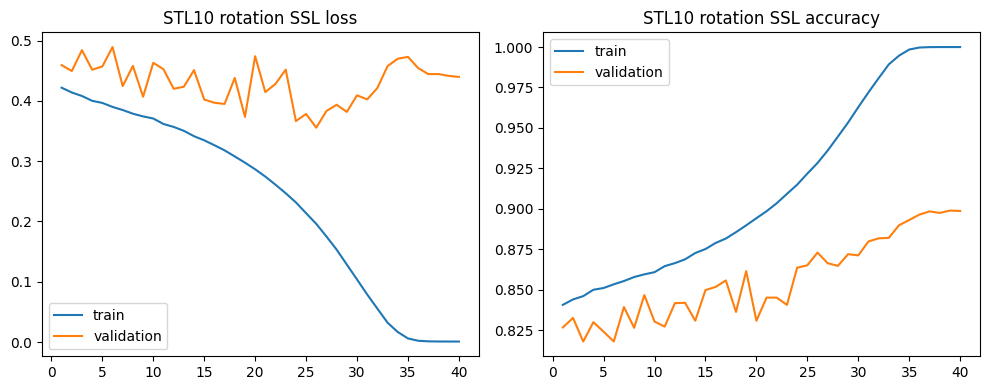

Final rotation validation accuracy: 0.8989
Above 40% requirement: True
Checkpoint: True results/ssl_backbone.pth


In [ ]:
epochs = range(1, len(history["val_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(epochs, history["train_loss"], label="train")
axes[0].plot(epochs, history["val_loss"], label="validation")
axes[0].set_title("STL10 rotation SSL loss")
axes[0].legend()
axes[1].plot(epochs, history["train_acc"], label="train")
axes[1].plot(epochs, history["val_acc"], label="validation")
axes[1].set_title("STL10 rotation SSL accuracy")
axes[1].legend()
fig.tight_layout()
fig.savefig(str(SSL_FIG_PATH), dpi=200, bbox_inches="tight")
plt.show()
print("Final rotation validation accuracy:", f"{history['final_val_acc']:.4f}")
print("Above 40% requirement:", history["final_val_acc"] > 0.40)
print("Checkpoint:", SSL_BACKBONE_PATH.exists(), SSL_BACKBONE_PATH)

In [4]:
print("Drive checkpoint:", SSL_BACKBONE_PATH.exists(), SSL_BACKBONE_PATH)
print("Drive history:", SSL_HISTORY_PATH.exists(), SSL_HISTORY_PATH)
print("Drive figure:", SSL_FIG_PATH.exists(), SSL_FIG_PATH)

'results/ssl_backbone.pth' NOT found in the results directory.
